In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Makes plots look professional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
df = pd.read_csv('../data/olist_orders_cleaned.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

print("Data loaded:", df.shape)
df.head()

Data loaded: (96455, 9)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_days
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2


In [3]:
print(df.dtypes)

order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
delivery_days                             int64
dtype: object


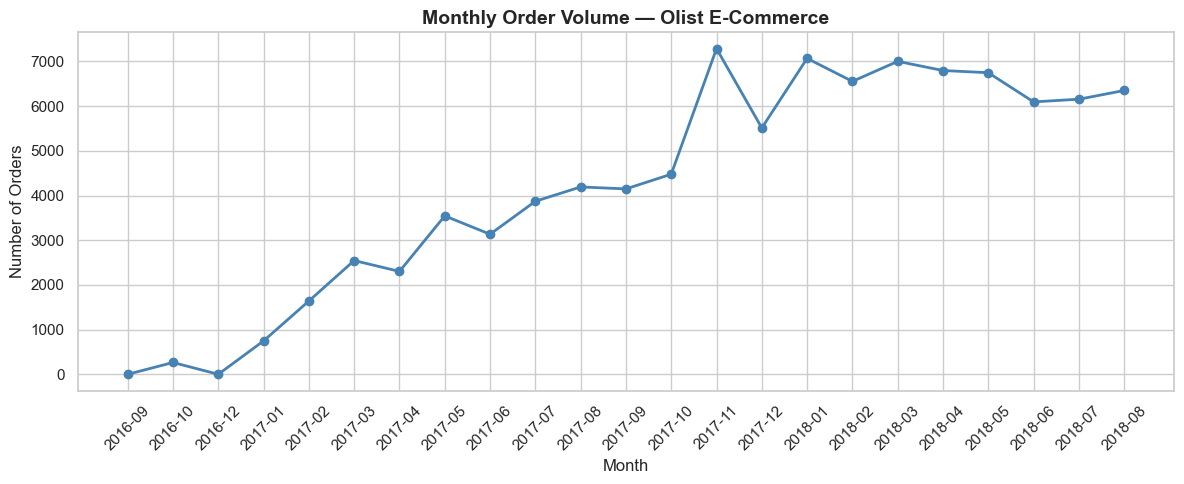

In [6]:
# Extract year-month from purchase timestamp
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M')

# Count orders per month
monthly_orders = df.groupby('order_month').size().reset_index(name='order_count')

# Convert period to string for plotting
monthly_orders['order_month'] = monthly_orders['order_month'].astype(str)

# Plot
fig, ax = plt.subplots()

ax.plot(monthly_orders['order_month'], 
        monthly_orders['order_count'], 
        marker='o', 
        linewidth=2, 
        color='steelblue')

ax.set_title('Monthly Order Volume — Olist E-Commerce', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../images/chart1_monthly_orders.png', dpi=150)
plt.show()

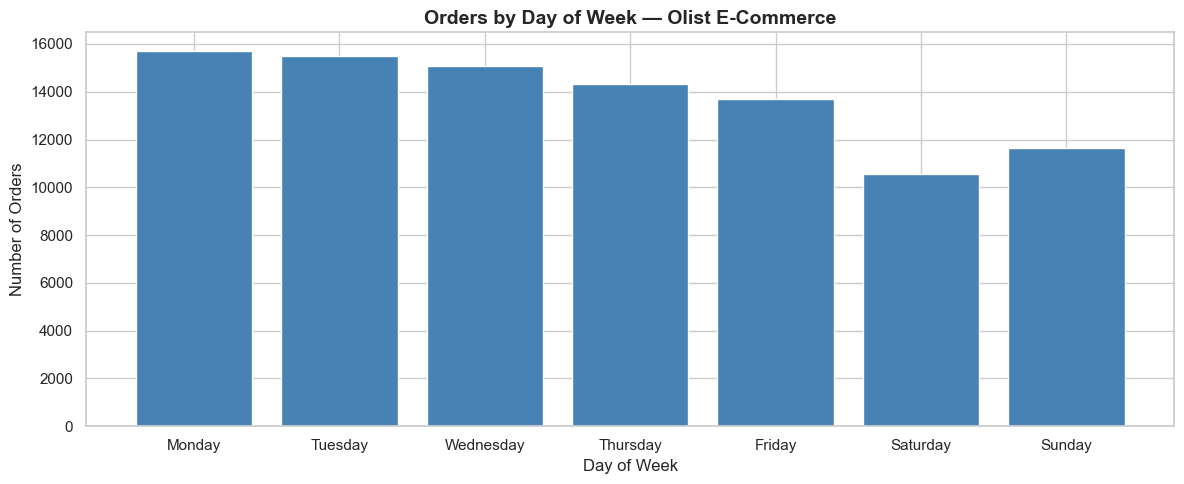

In [7]:
# Extract day of week (0=Monday, 6=Sunday)
df['day_of_week'] = df['order_purchase_timestamp'].dt.day_name()

# Define correct order
day_order = ['Monday', 'Tuesday', 'Wednesday', 
             'Thursday', 'Friday', 'Saturday', 'Sunday']

# Count orders per day
daily_orders = df.groupby('day_of_week').size().reindex(day_order).reset_index(name='order_count')

# Plot
fig, ax = plt.subplots()

bars = ax.bar(daily_orders['day_of_week'], 
              daily_orders['order_count'],
              color='steelblue',
              edgecolor='white')

ax.set_title('Orders by Day of Week — Olist E-Commerce', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../images/chart2_orders_by_day.png', dpi=150)
plt.show()

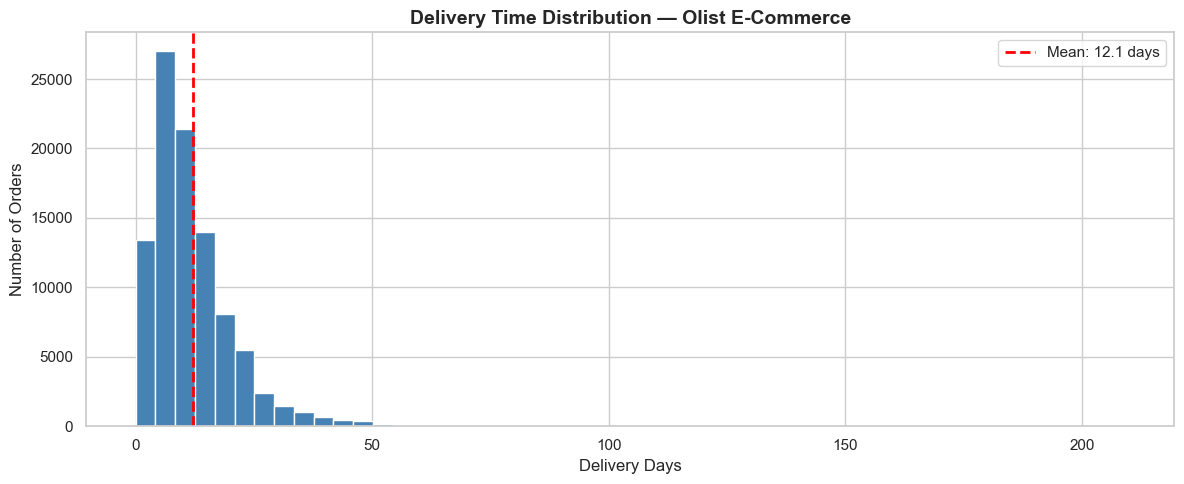

In [8]:
fig, ax = plt.subplots()

ax.hist(df['delivery_days'], 
        bins=50, 
        color='steelblue',
        edgecolor='white')

# Add a vertical line for the mean
ax.axvline(df['delivery_days'].mean(), 
           color='red', 
           linestyle='--', 
           linewidth=2,
           label=f"Mean: {df['delivery_days'].mean():.1f} days")

ax.set_title('Delivery Time Distribution — Olist E-Commerce', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Delivery Days')
ax.set_ylabel('Number of Orders')
ax.legend()
plt.tight_layout()
plt.savefig('../images/chart3_delivery_distribution.png', dpi=150)
plt.show()

On-time delivery rate: 91.9%
Late delivery rate: 8.1%


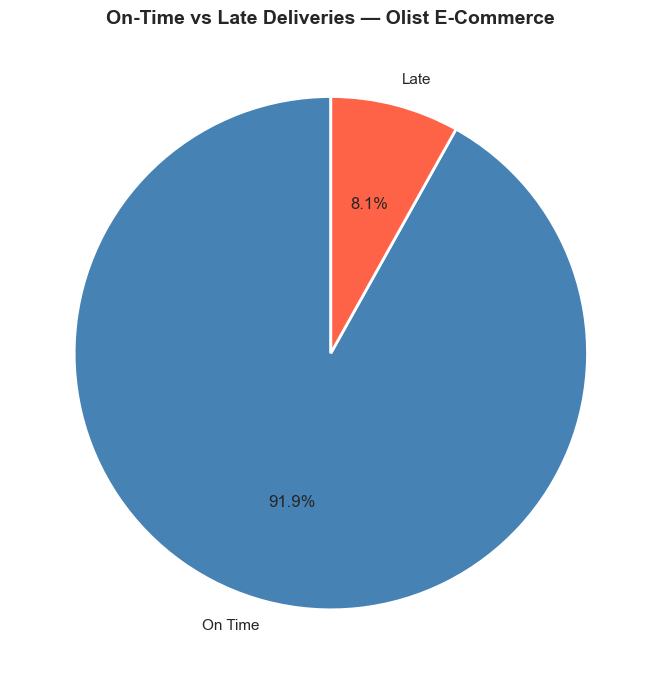

In [9]:
# Create a flag for late deliveries
df['is_late'] = df['order_delivered_customer_date'] > df['order_estimated_delivery_date']

# Calculate late delivery rate
late_rate = df['is_late'].mean() * 100
on_time_rate = 100 - late_rate

print(f"On-time delivery rate: {on_time_rate:.1f}%")
print(f"Late delivery rate: {late_rate:.1f}%")

# Plot
fig, ax = plt.subplots(figsize=(7, 7))

ax.pie([on_time_rate, late_rate],
       labels=['On Time', 'Late'],
       autopct='%1.1f%%',
       colors=['steelblue', 'tomato'],
       startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax.set_title('On-Time vs Late Deliveries — Olist E-Commerce',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/chart4_late_deliveries.png', dpi=150)
plt.show()

In [10]:
total_orders = len(df)
late_orders = df['is_late'].sum()
print(f"Total late orders: {late_orders:,} out of {total_orders:,}")

Total late orders: 7,825 out of 96,455


## EDA Summary & Business Insights

### Finding 1 — Strong Growth Trajectory
Orders grew from near zero (late 2016) to ~7,000/month by late 2017.
Notable spike in November 2017 — likely Black Friday seasonality effect.

### Finding 2 — Weekday Shopping Behavior  
Monday is the peak shopping day (~15,700 orders).
Saturday is the slowest day (~10,500 orders).
Recommendation: Schedule promotions and campaigns on Monday–Wednesday.

### Finding 3 — Delivery Time is Right-Skewed
Median delivery = 10 days. Mean = 12.1 days (inflated by outliers).
Most customers receive orders within 5–15 days.
A small number of extreme outliers (50–200 days) distort the average.

### Finding 4 — 8.1% Late Delivery Rate
~7,800 orders were delivered after the estimated date.
This represents a significant operational risk — unhappy customers,
negative reviews, and potential refund costs.
Recommendation: Investigate which regions/sellers drive late deliveries.